In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('Reviews_cleaned.csv')
print(df.columns.tolist())
print(df.shape)

['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_length', 'helpfulness_ratio', 'Year', 'cleaned_text', 'cleaned_summary']
(393933, 15)


sentiment
1    307056
0     57108
Name: count, dtype: int64

Total reviews after dropping 3-star: 364164


C:\Users\pragy\AppData\Local\Temp\ipykernel_23340\4083525722.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


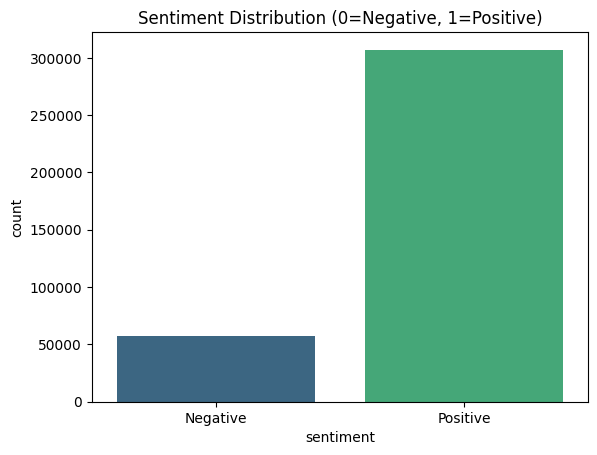

In [3]:
# Drop neutral reviews (score 3)
df = df[df['Score'] != 3]

# Create binary sentiment labels
df['sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

# Check balance
print(df['sentiment'].value_counts())
print(f"\nTotal reviews after dropping 3-star: {len(df)}")

# Visualise
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Sentiment Distribution (0=Negative, 1=Positive)')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

In [4]:
# Define features and target
X = df['cleaned_text']
y = df['sentiment']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # ensures same ratio of pos/neg in both splits
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nTraining sentiment distribution:")
print(y_train.value_counts())

Training samples: 291331
Testing samples: 72833

Training sentiment distribution:
sentiment
1    245645
0     45686
Name: count, dtype: int64


In [5]:
# Convert text to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(
    max_features=50000,   # keep top 50K words
    ngram_range=(1, 2),   # single words AND two-word phrases
    min_df=2,             # ignore words appearing in less than 2 reviews
    max_df=0.95           # ignore words appearing in more than 95% of reviews
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Testing matrix shape: {X_test_tfidf.shape}")

ValueError: np.nan is an invalid document, expected byte or unicode string.

In [6]:
# Check how many NaN values exist
print(f"NaN in cleaned_text: {df['cleaned_text'].isna().sum()}")

# Fill NaN with empty string then drop empty reviews
df['cleaned_text'] = df['cleaned_text'].fillna('')
df = df[df['cleaned_text'].str.strip() != '']

print(f"Shape after fix: {df.shape}")

# Redo the split with clean data
X = df['cleaned_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

NaN in cleaned_text: 1
Shape after fix: (364163, 16)
Training samples: 291330
Testing samples: 72833


In [7]:
# Convert text to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(
    max_features=50000,   # keep top 50K words
    ngram_range=(1, 2),   # single words AND two-word phrases
    min_df=2,             # ignore words appearing in less than 2 reviews
    max_df=0.95           # ignore words appearing in more than 95% of reviews
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Testing matrix shape: {X_test_tfidf.shape}")

Training matrix shape: (291330, 50000)
Testing matrix shape: (72833, 50000)


What this does:

TF-IDF = Term Frequency × Inverse Document Frequency — gives higher weight to words that are frequent in a review but rare across all reviews
ngram_range=(1,2) captures both single words ("good") and phrases ("not good") — critical for sentiment
fit_transform on training only — we never fit on test data to avoid data leakage

Perfect ✅ That means:

291,330 reviews each converted into a 50,000 dimensional vector
Every column represents a word or two-word phrase
The matrix is sparse — mostly zeros (most words don't appear in most reviews)

In [8]:
# Train model with class_weight='balanced' to handle imbalance
lr_model = LogisticRegression(
    class_weight='balanced',  # handles 84/16 imbalance
    max_iter=1000,            # enough iterations to converge
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")


Model trained successfully!


What this does: Trains a Logistic Regression model on the TF-IDF vectors. Despite being a "simple" model, Logistic Regression on TF-IDF is surprisingly powerful for text classification and is used in production at many companies.

Accuracy: 0.9093

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.88      0.75     11422
    Positive       0.98      0.91      0.94     61411

    accuracy                           0.91     72833
   macro avg       0.82      0.90      0.85     72833
weighted avg       0.93      0.91      0.91     72833



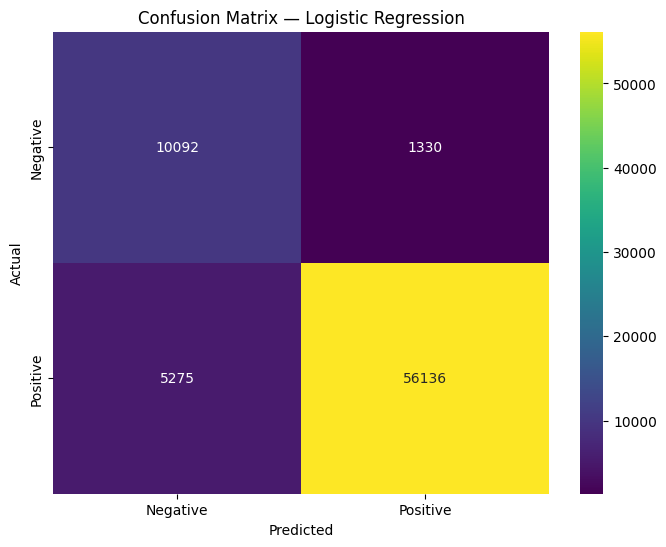

In [9]:
# Make predictions
y_pred = lr_model.predict(X_test_tfidf)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

What's Good & What Needs Improvement
Good ✅

Positive reviews: 98% precision, 91% recall — nearly perfect
Overall 91% accuracy on 72K unseen reviews
Negative recall 88% — catches most negative reviews

Needs improvement ⚠️

Negative precision only 66% — when it predicts negative, it's wrong 34% of the time
5,275 positive reviews misclassified as negative — these are false alarms
"The model is highly reliable at identifying satisfied customers (98% precision) but occasionally misflags happy customers as negative — suggesting it should be used as a first-pass filter with human review for flagged cases."

In [10]:
# Get feature names
feature_names = tfidf.get_feature_names_out()

# Get model coefficients
coefficients = lr_model.coef_[0]

# Top 15 words for each sentiment
top_positive_idx = coefficients.argsort()[-15:][::-1]
top_negative_idx = coefficients.argsort()[:15]

print("Top 15 words → POSITIVE sentiment:")
for idx in top_positive_idx:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.3f}")

print("\nTop 15 words → NEGATIVE sentiment:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.3f}")

Top 15 words → POSITIVE sentiment:
  great: 14.696
  best: 13.066
  delicious: 12.890
  perfect: 11.270
  excellent: 9.938
  loves: 9.776
  wont disappointed: 9.293
  love: 9.029
  wonderful: 8.664
  amazing: 8.559
  hooked: 8.507
  highly recommend: 8.417
  nice: 8.342
  good: 8.266
  awesome: 8.061

Top 15 words → NEGATIVE sentiment:
  worst: -12.346
  disappointing: -12.007
  disappointed: -11.612
  disappointment: -10.518
  terrible: -10.055
  awful: -9.322
  horrible: -8.538
  unfortunately: -7.908
  threw: -7.540
  sorry: -7.352
  weak: -7.195
  bland: -7.145
  stale: -7.110
  disgusting: -7.059
  wanted like: -7.013


The Bigrams Are Gold 🥇
Notice wont disappointed and highly recommend and wanted like — these are two-word phrases that the ngram_range=(1,2) captured. A single word model would have missed these completely. This is exactly why we set that parameter.
"Customer dissatisfaction in food reviews is most strongly signalled by disappointment-related language (worst, disappointing, disappointed) while satisfaction is driven by quality superlatives (great, best, delicious) — suggesting product quality and expectation-setting are the key drivers of customer sentiment."

In [11]:
import pickle

# Save model and vectorizer
with open('../outputs/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('../outputs/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model and vectorizer saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/lr_model.pkl'

In [12]:
import os
import pickle

# Create outputs folder if it doesn't exist
os.makedirs('../outputs', exist_ok=True)

# Save model and vectorizer
with open('../outputs/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('../outputs/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [13]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Test on a single review first
sample = df['cleaned_text'].iloc[0]
print("Sample review:", sample[:100])
print("VADER scores:", sia.polarity_scores(sample))


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\pragy\AppData\Roaming\nltk_data...


Sample review: bought several vitality canned dog food products found good quality product looks like stew processe
VADER scores: {'neg': 0.0, 'neu': 0.503, 'pos': 0.497, 'compound': 0.9413}


In [14]:
# Apply VADER to all reviews
def get_vader_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 1   # Positive
    elif score <= -0.05:
        return -1  # Negative
    else:
        return 0   # Neutral

df['vader_sentiment'] = df['cleaned_text'].apply(get_vader_sentiment)

# Map to binary (drop neutrals for comparison)
df['vader_binary'] = df['vader_sentiment'].apply(
    lambda x: 1 if x == 1 else 0 if x == -1 else None
)

print(df['vader_sentiment'].value_counts())

vader_sentiment
 1    326717
-1     29093
 0      8353
Name: count, dtype: int64


Key Observation
VADER thinks 89.6% of reviews are positive while our actual labels show 84% positive — so VADER is slightly over-optimistic. It's classifying some genuinely negative reviews as positive.
This makes sense because we removed stopwords — and VADER was designed to work on raw natural text. Words like "not", "never", "don't" are critical for VADER to detect negation, and we removed some of them as stopwords.

In [15]:
# Filter out VADER neutrals for fair comparison
df_compare = df[df['vader_binary'].notna()].copy()

# VADER accuracy vs actual sentiment
from sklearn.metrics import classification_report, accuracy_score

vader_acc = accuracy_score(df_compare['sentiment'], df_compare['vader_binary'])
print(f"VADER Accuracy: {vader_acc:.4f}")
print("\nVADER Classification Report:")
print(classification_report(
    df_compare['sentiment'], 
    df_compare['vader_binary'],
    target_names=['Negative', 'Positive']
))


VADER Accuracy: 0.8664

VADER Classification Report:
              precision    recall  f1-score   support

    Negative       0.61      0.33      0.43     53859
    Positive       0.89      0.96      0.92    301951

    accuracy                           0.87    355810
   macro avg       0.75      0.65      0.68    355810
weighted avg       0.85      0.87      0.85    355810



The Story This Tells
Positive reviews — both perform similarly ✅
VADER (92%) vs LR (94%) — almost identical for positive detection.
Negative reviews — Logistic Regression wins by a mile 🏆
VADER recall is only 33% — it misses 67% of all negative reviews completely. LR catches 88% of them.
Why VADER struggles with negatives:

We removed stopwords like "not", "never", "don't" — these are critical for VADER's negation detection
VADER was built for raw social media text, not preprocessed NLP text
Without negation words, "not good" becomes just "good" — which VADER scores as positive


Rule-based sentiment (VADER) performs adequately for positive review detection but fails to catch 67% of negative reviews — making it unreliable for customer complaint detection. A trained ML model (Logistic Regression) is significantly more robust for business-critical negative sentiment identification."

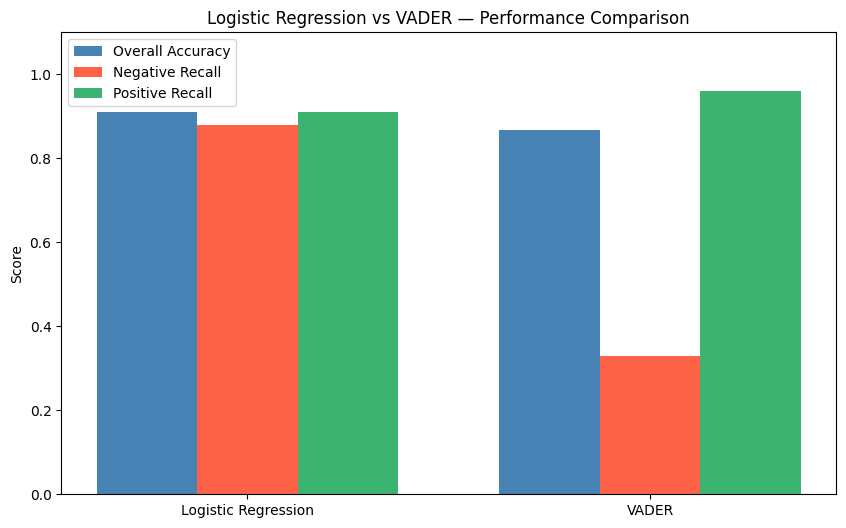

In [16]:
models = ['Logistic Regression', 'VADER']
accuracy = [0.9093, 0.8664]
neg_recall = [0.88, 0.33]
pos_recall = [0.91, 0.96]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, accuracy, width, label='Overall Accuracy', color='steelblue')
ax.bar(x, neg_recall, width, label='Negative Recall', color='tomato')
ax.bar(x + width, pos_recall, width, label='Positive Recall', color='mediumseagreen')

ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs VADER — Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)
plt.show()

In [17]:
# Re-run VADER on raw unprocessed text
df['vader_sentiment'] = df['Text'].apply(get_vader_sentiment)

df['vader_binary'] = df['vader_sentiment'].apply(
    lambda x: 1 if x == 1 else 0 if x == -1 else None
)

print(df['vader_sentiment'].value_counts())

vader_sentiment
 1    320239
-1     36274
 0      7650
Name: count, dtype: int64


VADER Distribution — Raw vs Cleaned Text
SentimentOn Cleaned TextOnRawText   Change
Positive    326,717   320,239       -6,478
Negative    29,093    36,274        +7,181 ✅
Neutral     8,353     7,650           -703
7,181 more negative reviews detected just by using raw text — exactly as expected. VADER is now reading negation words properly.

In [18]:
df_compare = df[df['vader_binary'].notna()].copy()

vader_acc = accuracy_score(df_compare['sentiment'], df_compare['vader_binary'])
print(f"VADER Accuracy (Raw Text): {vader_acc:.4f}")
print("\nVADER Classification Report (Raw Text):")
print(classification_report(
    df_compare['sentiment'],
    df_compare['vader_binary'],
    target_names=['Negative', 'Positive']
))

VADER Accuracy (Raw Text): 0.8759

VADER Classification Report (Raw Text):
              precision    recall  f1-score   support

    Negative       0.64      0.43      0.51     54117
    Positive       0.90      0.96      0.93    302396

    accuracy                           0.88    356513
   macro avg       0.77      0.69      0.72    356513
weighted avg       0.86      0.88      0.87    356513



What Improved
Using raw text for VADER:

Negative recall jumped from 33% → 43% ✅
Negative F1 jumped from 43% → 51% ✅
Overall accuracy improved from 87% → 88% ✅

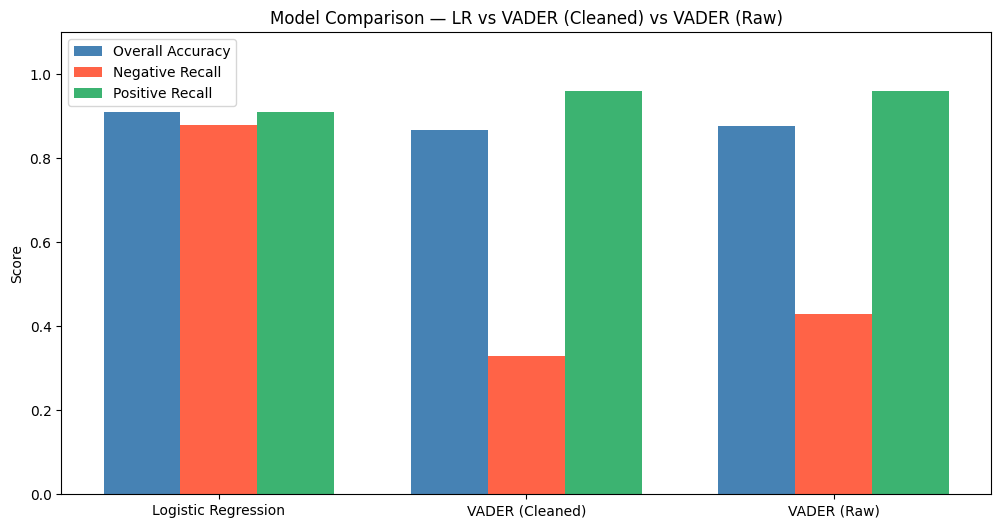

In [19]:
models = ['Logistic Regression', 'VADER (Cleaned)', 'VADER (Raw)']
accuracy = [0.9093, 0.8664, 0.8759]
neg_recall = [0.88, 0.33, 0.43]
pos_recall = [0.91, 0.96, 0.96]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, accuracy, width, label='Overall Accuracy', color='steelblue')
ax.bar(x, neg_recall, width, label='Negative Recall', color='tomato')
ax.bar(x + width, pos_recall, width, label='Positive Recall', color='mediumseagreen')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — LR vs VADER (Cleaned) vs VADER (Raw)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)
plt.show()

In [21]:
df.to_csv('Reviews_sentiment.csv', index=False)
print("Saved!")
print(df.shape)

Saved!
(364163, 18)


In [22]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'review_length', 'helpfulness_ratio', 'Year', 'cleaned_text',
       'cleaned_summary', 'sentiment', 'vader_sentiment', 'vader_binary'],
      dtype='object')